# 07 — From $p_1$ and $p_0$ to milliseconds

Every previous notebook produced two numbers per configuration: $p_1$ (an aligned cell fires)
and $p_0$ (a wrong cell fires). This notebook turns them into the quantity the project
actually reports — **acquisition time** — and draws the curve the whole study exists to
produce.

The chain is short but every link matters:

$$ p_1, p_0 \;\longrightarrow\; \text{Binomial}(MS, p) \;\longrightarrow\; k \;\text{from the Pfa budget} \;\longrightarrow\; M \;\text{from } P_d \ge 0.9 \;\longrightarrow\; \text{milliseconds} $$

By the end you should be able to answer:

1. Why is a *binomial* the right model, and is its independence assumption actually true?
2. How does a 1.34 M-cell search set the per-cell threshold?
3. Why is $k$ chosen before $M$, and not jointly?
4. What does the area-vs-time trade look like when you plot it?

Modules: [`experiments.dwells_required`](../sim/gps/experiments.py),
[`sim/gps/segmentation_study.py`](../sim/gps/segmentation_study.py).

In [1]:
import sys, pathlib, math
ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom, chisquare

from sim.gps import codebook
from sim.gps.experiments import (GpsConfig, cached_distances, dictionary_bits,
                                 dwells_required, independent_cells)
from sim.gps.segmentation_study import run as seg_run

# sim/plots.py forces the Agg backend at import; restore inline rendering.
%matplotlib inline

plt.rcParams.update({"figure.figsize": (9, 3), "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 9})
TRIALS, SEED = 3000, 42
TARGET_PD, SYSTEM_PFA = 0.9, 0.01

---
## 1. The accumulation model

Notebook 05 showed `detect` accumulates fire counts over segments *and* dwells. After $M$
dwells of $S$ segments each, the statistic is a count out of $n = MS$ Bernoulli trials:

$$ \text{count} \sim \text{Binomial}(MS,\, p), \qquad p = \begin{cases} p_1 & \text{signal present} \\ p_0 & \text{otherwise} \end{cases} $$

Declare a detection when $\text{count} \ge k$.

This is a **modelling assumption**, not a fact: it requires the segment fires to be
independent. They plausibly are — different segments see different noise — but "plausibly" is
not good enough for the number the paper reports, so let's check it.

In [2]:
print("Observed fire-count distribution vs Binomial(S, p0), at the study's chosen tau:\n")
for S, tau in [(6, 321), (11, 169)]:
    d = cached_distances(GpsConfig(n_segments=S, n_prn=3), 38.0, TRIALS, SEED)
    w = np.concatenate([d[k] for k in ("wrong_phase", "wrong_doppler", "wrong_prn")])
    fires = (w <= tau).sum(1)
    p = (w <= tau).mean()
    obs = np.bincount(fires, minlength=S + 1)[:S + 1]
    exp = binom.pmf(np.arange(S + 1), S, p) * len(fires)
    keep = exp > 5
    _, pv = chisquare(obs[keep], exp[keep] * obs[keep].sum() / exp[keep].sum())
    print(f"S={S:2d}, tau={tau}, p0={p:.4f}")
    print(f"   observed : {obs}")
    print(f"   binomial : {exp.round(0).astype(int)}")
    print(f"   variance : {fires.var():.3f} observed vs {S*p*(1-p):.3f} binomial")
    print(f"   chi2 p-value {pv:.3f} -> {'consistent with independence' if pv > 0.01 else 'NOT independent'}\n")

Observed fire-count distribution vs Binomial(S, p0), at the study's chosen tau:

S= 6, tau=321, p0=0.2521
   observed : [1553 3225 2680 1181  321   38    2]
   binomial : [1575 3185 2685 1207  305   41    2]
   variance : 1.127 observed vs 1.131 binomial
   chi2 p-value 0.789 -> consistent with independence

S=11, tau=169, p0=0.1648
   observed : [1188 2788 2619 1570  638  160   30    6    1    0    0    0]
   binomial : [1241 2694 2659 1574  621  172   34    5    0    0    0    0]
   variance : 1.495 observed vs 1.514 binomial
   chi2 p-value 0.252 -> consistent with independence



Both pass comfortably, and the variances match to three decimals — which is the sharper test,
since correlated segments would show *over*-dispersion. The binomial model is earned, not
assumed.

> Worth noticing what makes this true: the segments are contiguous slices of one dwell, so
> they share nothing but the (deterministic) row. Had we accumulated overlapping windows, or
> reused the same noise across quadrants, this check would have failed — and the dwell counts
> downstream would have been optimistic.

---
## 2. The false-alarm budget sets $k$

Here is where the 1.34 M cells of notebook 01 finally bite. We want **at most 1% probability
that the whole search produces any false detection**. With $N_{\text{cells}}$ independent
opportunities, a union bound gives each cell:

$$ P_{fa}^{\text{cell}} \;\le\; \frac{P_{fa}^{\text{system}}}{N_{\text{cells}}} $$

$k$ is then the smallest threshold meeting that, and it is chosen **first** — before $M$ —
because it is a hard constraint, whereas $M$ is what we are minimizing.

In [3]:
for S in [1, 6, 11]:
    cells = independent_cells(GpsConfig(n_segments=S, n_prn=32))
    print(f"S={S:2d}: {cells:>10,} cells -> per-cell budget {SYSTEM_PFA/cells:.2e}")
print()
print("Note the budget LOOSENS as S grows: fewer Doppler rows means fewer cells to search.")
print("That is a third, smaller benefit of segmentation, on top of area and sense margin.")

S= 1:  1,342,176 cells -> per-cell budget 7.45e-09
S= 6:    294,624 cells -> per-cell budget 3.39e-08
S=11:    163,680 cells -> per-cell budget 6.11e-08

Note the budget LOOSENS as S grows: fewer Doppler rows means fewer cells to search.
That is a third, smaller benefit of segmentation, on top of area and sense margin.


---
## 3. A worked example, one dwell count at a time

Take $S=6$, and suppose $p_1 = 0.45$, $p_0 = 0.12$. Walk $M$ upward. At each $M$: compute the
smallest legal $k$, then see whether $P_d$ has reached 0.9 yet.

In [4]:
S, p1, p0 = 6, 0.45, 0.12
cells = independent_cells(GpsConfig(n_segments=S, n_prn=32))
budget = SYSTEM_PFA / cells

print(f"S={S}, p1={p1}, p0={p0}, budget={budget:.2e}\n")
print(f"{'M':>4} {'n=MS':>6} {'k':>5} {'per-cell Pfa':>14} {'Pd':>8}")
shown = False
for m in [1, 2, 5, 10, 12, 15, 20]:
    n = m * S
    k = max(1, min(int(binom.isf(budget, n, p0)) + 1, n))
    if binom.sf(k - 1, n, p0) > budget:
        k += 1
    pd = binom.sf(k - 1, n, p1) if k <= n else 0.0
    flag = ""
    if pd >= TARGET_PD and not shown:
        flag, shown = "  <-- first M with Pd >= 0.9", True
    print(f"{m:>4} {n:>6} {k:>5} {binom.sf(k-1, n, p0):>14.2e} {pd:>8.3f}{flag}")

m, k = dwells_required(p1, p0, S, cells)
print(f"\ndwells_required() agrees: M={m}, k={k}")

S=6, p1=0.45, p0=0.12, budget=3.39e-08

   M   n=MS     k   per-cell Pfa       Pd
   1      6     7       0.00e+00    0.000
   2     12    10       3.24e-08    0.008
   5     30    17       5.59e-09    0.136
  10     60    25       6.89e-09    0.741
  12     72    27       2.61e-08    0.920  <-- first M with Pd >= 0.9
  15     90    31       2.62e-08    0.984
  20    120    38       1.07e-08    0.999

dwells_required() agrees: M=12, k=27


Read the $k$ column: it grows roughly like $M p_0$ plus a few standard deviations, while the
detection count grows like $M p_1$. Since $p_1 > p_0$, the two diverge — slowly. **That
divergence rate is the entire performance of the system.** Everything the architecture does
well or badly shows up as a change in $p_1 - p_0$.

Notice also the shape of the failure at small $M$: at $M=1$, $k=7$ out of $n=6$ is impossible,
so $P_d = 0$. There is a minimum number of dwells below which no threshold works at all,
purely from the granularity of a count.

---
## 4. The real sweep

The study does not fix $\tau$; it sweeps $\tau$, computes $(p_1, p_0)$ for each, and keeps
whichever gives the fewest dwells. That is
[`segmentation_study.run`](../sim/gps/segmentation_study.py).

In [5]:
res = seg_run(trials=TRIALS, seed=SEED)

print(f"{'S':>3} {'T_coh':>9} {'rows':>5} {'dict':>10} {'tau':>6} {'k':>5} "
      f"{'p1':>6} {'p0':>7} {'dwells@38':>10} {'dwells@42':>10}")
for i, S in enumerate(res["segments"]):
    cf = GpsConfig(n_segments=int(S))
    print(f"{S:>3} {cf.t_coh*1e6:>7.0f}us {res['n_doppler'][i]:>5} "
          f"{res['dict_bits'][i]/1e6:>7.2f} Mb {res['tau'][i,0]:>6} {res['k'][i,0]:>5} "
          f"{res['p1'][i,0]:>6.3f} {res['p0'][i,0]:>7.4f} "
          f"{res['dwells'][i,0]:>8} ms {res['dwells'][i,1]:>8} ms")

  S     T_coh  rows       dict    tau     k     p1      p0  dwells@38  dwells@42
  1    1000us    41    5.37 Mb   1976    10  0.721  0.0566       17 ms        6 ms
  2     500us    21    2.75 Mb    975    17  0.454  0.0733       23 ms        7 ms
  3     333us    15    1.96 Mb    650    36  0.512  0.1733       27 ms        7 ms
  6     167us     9    1.18 Mb    321   104  0.452  0.2550       42 ms       10 ms
 11      91us     5    0.65 Mb    169   177  0.268  0.1687       65 ms       13 ms


A few things to read off that table rather than skim past:

- **$p_0$ is not small.** At $S=6$ a wrong cell fires a quarter of the time. That is fine —
  the protection comes from needing $k=104$ fires out of $MS$, not from any single segment
  being reliable.
- **$p_1$ is not close to 1 either** (0.27–0.72). The detector is built out of unreliable
  parts on purpose; reliability is manufactured by counting.
- **The chosen $\tau$ tracks the segment width**, roughly $0.47\,W_{\text{seg}}$ throughout —
  just below chance, as notebook 06's basin predicted.

---
## 5. The headline: area against time

Now put the two costs on one plot. Every point is a value of $S$; moving along the curve
trades dictionary bits for milliseconds.

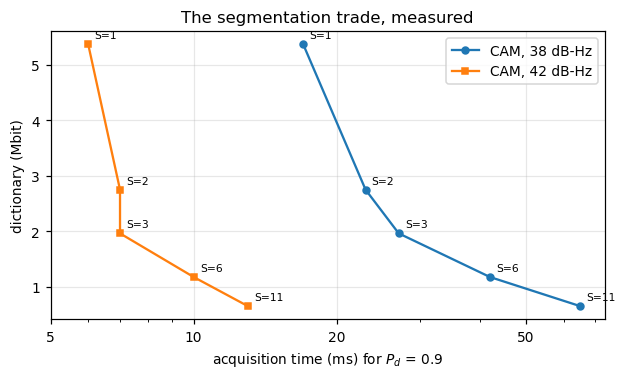

The knee is real: S=1 -> S=2 saves half the dictionary for +6 ms,
but S=6 -> S=11 saves only 0.5 Mbit and costs another 23 ms.


In [6]:
fig, ax = plt.subplots(figsize=(6.5, 3.4))
for j, cn0 in enumerate(res["cn0s"]):
    m = res["dwells"][:, j].astype(float)
    ok = m > 0
    ax.plot(m[ok], res["dict_bits"][ok] / 1e6, "os"[j] + "-", ms=4.5,
            label=f"CAM, {cn0:.0f} dB-Hz")
    for i, S in enumerate(res["segments"]):
        if ok[i]:
            ax.annotate(f"S={S}", (m[i], res["dict_bits"][i] / 1e6),
                        textcoords="offset points", xytext=(4, 4), fontsize=7)
ax.set(xscale="log", xlabel="acquisition time (ms) for $P_d$ = 0.9",
       ylabel="dictionary (Mbit)", title="The segmentation trade, measured")
ax.set_xticks([5, 10, 20, 50]); ax.set_xticklabels(["5", "10", "20", "50"])
ax.legend(); plt.show()

print("The knee is real: S=1 -> S=2 saves half the dictionary for +6 ms,")
print("but S=6 -> S=11 saves only 0.5 Mbit and costs another 23 ms.")

In [7]:
print(f"{'S':>3} {'dict (Mbit)':>12} {'time@38 (ms)':>13} {'Mbit saved':>11} {'ms paid':>9} {'Mbit/ms':>9}")
prev = None
for i, S in enumerate(res["segments"]):
    mb, ms = res["dict_bits"][i] / 1e6, res["dwells"][i, 0]
    if prev is None:
        print(f"{S:>3} {mb:>12.2f} {ms:>13} {'-':>11} {'-':>9} {'-':>9}")
    else:
        dmb, dms = prev[0] - mb, ms - prev[1]
        print(f"{S:>3} {mb:>12.2f} {ms:>13} {dmb:>11.2f} {dms:>9} {dmb/dms:>9.3f}")
    prev = (mb, ms)
print(f"\nMarginal return collapses {0.436/0.023:.0f}x from the first step to the last.")

  S  dict (Mbit)  time@38 (ms)  Mbit saved   ms paid   Mbit/ms
  1         5.37            17           -         -         -
  2         2.75            23        2.62         6     0.436
  3         1.96            27        0.79         4     0.196
  6         1.18            42        0.79        15     0.052
 11         0.65            65        0.52        23     0.023

Marginal return collapses 19x from the first step to the last.


**So the design recommendation is not "segment as much as possible".** The efficient region is
$S = 1$–$3$; beyond that you are paying milliseconds for very little area. That is a
conclusion the curve produces and prose could not — and it is the reason this study is a
sweep rather than a single operating point.

---
## 6. Where the model could mislead you

Three assumptions hold this number up. Two we have checked; one we have not.

| Assumption | Status |
|---|---|
| Segment fires are independent | **checked** in §1 — $\chi^2$ passes, variance matches |
| Cells are independent (union bound over 1.34 M) | **partly** — chip-spaced phases are, but neighbouring Doppler bins are correlated (notebook 03 §3), so the bound is conservative |
| $p_1, p_0$ estimated from 3000 trials are accurate enough | **worth checking** — they are $O(0.1)$, so the standard error is small, but they get raised to the power $MS$ |

The third deserves a number rather than a shrug.

In [8]:
S, i, j = 6, 3, 0
cells = independent_cells(GpsConfig(n_segments=S, n_prn=32))
p1, p0 = res["p1"][i, j], res["p0"][i, j]
se1, se0 = math.sqrt(p1*(1-p1)/TRIALS), math.sqrt(p0*(1-p0)/(3*TRIALS))
print(f"S={S}: p1={p1:.4f} +/- {se1:.4f},  p0={p0:.4f} +/- {se0:.4f}  (1 sigma)\n")
print(f"{'scenario':>22} {'M':>4}")
print(f"{'nominal':>22} {dwells_required(p1, p0, S, cells)[0]:>4}")
print(f"{'p1 low, p0 high (1s)':>22} {dwells_required(p1-se1, p0+se0, S, cells)[0]:>4}")
print(f"{'p1 high, p0 low (1s)':>22} {dwells_required(p1+se1, p0-se0, S, cells)[0]:>4}")
print(f"{'p1 low, p0 high (2s)':>22} {dwells_required(p1-2*se1, p0+2*se0, S, cells)[0]:>4}")

S=6: p1=0.4519 +/- 0.0091,  p0=0.2550 +/- 0.0046  (1 sigma)

              scenario    M
               nominal   42
  p1 low, p0 high (1s)   50
  p1 high, p0 low (1s)   37
  p1 low, p0 high (2s)   57


A $\pm1\sigma$ wobble in the measured rates moves $M$ from 42 to somewhere in **37–50 ms**
(about $\pm20\%$), and an adverse $2\sigma$ takes it to 57 ms. That is not negligible — it is
larger than the $S{=}6 \to S{=}11$ area saving is worth — so the individual dwell counts
should be read as approximate.

What it does *not* threaten is the ordering. The measured values across $S$ (17, 23, 27, 42,
65 ms) are separated by far more than this, so the shape of the curve and the "efficient
region is $S = 1$–$3$" conclusion both survive. The honest statement is: **trust the curve,
not the third significant figure** — and if you needed the individual numbers tighter, the
fix is more trials, and now you know roughly how many.

(This is also why the repo caches on a hash of *every* parameter including the trial count: a
result computed at a different `--trials` is a different result, and must not be silently
reused.)

---
## What we established

| Fact | Consequence |
|---|---|
| Fire counts are $\text{Binomial}(MS, p)$ — $\chi^2$ verified | the whole sizing chain is legitimate |
| Per-cell budget is $3.4\times10^{-8}$ ($S=6$) up to $7.5\times10^{-9}$ ($S=1$) | segmentation loosens the budget too |
| $k$ from the budget, *then* $M$ from $P_d$ | a constraint, then a minimization |
| At $S=6$, $p_0 = 0.26$ and $p_1 = 0.45$ | reliability is manufactured by counting, not by good parts |
| 38 dB-Hz: 17 ms ($S{=}1$) → 65 ms ($S{=}11$) | the measured area/time curve |
| Marginal return falls ~19× along the curve | **the efficient region is $S = 1$–$3$** |
| $\pm1\sigma$ on $p_1,p_0$ moves $M$ by $\pm20\%$ | trust the curve's shape, not the exact ms |

## Next

**Notebook 08 — `comparison.ipynb`.** The last question: is any of this *good*? We put the CAM
against the conventional FFT parallel-code-phase search, and — crucially — against the same
search driven from 1-bit samples, so that the 1.96 dB the front end was always going to cost
is not charged to the architecture. That decomposition is what turns a raw number into an
honest one.

### Try it yourself
- In §3, try $p_1 = 0.45, p_0 = 0.40$. How many dwells? Why does it blow up so fast?
- The union bound in §2 is conservative. If you replaced 1.34 M cells with an effective 0.5 M, how much would the dwell counts change?
- Re-run §5 at 42 dB-Hz only. Does the knee move?